# 숙제 3

데이터과학 입문

원중호 (서울대학교 통계학과)  
June 2026

## 지시사항

제출마감 2026-06-15 23:00

1.  R과 Python을 모두 사용하여 사용된 코드와 데이터랭글링 절차,
    분석결과를 설명한다. 두 언어의 분석결과가 차이가 있으면 그 이유를
    설명한다.
2.  [Quarto
    Markdown](https://quarto.org/docs/authoring/markdown-basics.html)을
    사용한다. 제공된 숙제 `.qmd` 파일에 본인의 답안을 “답안” 절에
    추가하여 제출한다. Quarto Markdown은 RStudio 또는 Visual Studio
    Code에 [Quarto
    Extension](https://marketplace.visualstudio.com/items?itemName=quarto.quarto)을
    추가하여 컴파일, 다른 문서 형식으로 변환할 수 있다.
3.  R의 `reticulate` 패키지를 사용하면 하나의 `.qmd` 파일 안에서 R과
    Python을 동시에 사용할 수 있다. 이때 다음 문법을 사용하여 두 언어
    코드를 탭으로 구분한다. 숙제 `.qmd` 파일은 `reticulate`을 사용하도록
    준비되어 있다.

```` markdown
::: {.panel-tabset}

## R

```{r}
R code
```

## Python

```{python}
Python code
```

:::
````

1.  `.qmd`를 컴파일하여 생성된 `.html` 파일을 함께 저장소에 제출한다.
2.  함께 제공된 `student.yml`을 함께 작성하여 저장소에 제출한다.

## 평가 기준

1.  재현성: 제출된 저장소의 `.qmd` 파일을 컴파일하여 함께 제출된 `.html`
    파일과 동일한 결과가 나와야 한다.
2.  분석의 정확성: 분석은 올바른 기술적 세부 사항을 포함하여 수행되어야
    한다.
3.  보고서의 전반적인 품질: 데이터 가공 및 분석 결과가 명확하고 자세하게
    설명되어야 한다.
4.  코드의 전반적인 품질: 코드는 체계적으로 정리되어 있어야 하며,
    가독성을 높이기 위해 적절한 주석이 포함되어야 한다.

#### **늦게 제출된 과제물은 받지 않는다.**

## 공통 패키지 적재

먼저 1부, 2부 분석에 공통적으로 사용할 패키지를 불러온다.

## R

``` r
library(tidyverse)
library(Lahman)
library(NHANES)
library(MASS, exclude = "select")   # stepAIC, glm.nb 사용
library(broom)                      # tidy(), augment()
library(knitr)                      # kable()
```

## Python

``` python
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy import stats
import matplotlib.pyplot as plt
```

# 1부 교과서 연습문제

## 문제 1-1

1.  MDSR 10장 연습문제 10.6.6

### 답안

**문제**: `NHANES` 패키지의 데이터를 이용하여 20세 이상의 성인 중 현재
흡연자(*current smoker*)를 식별하는 로지스틱 회귀모형을 적합한다. 단,
`SmokeNow` 변수는 평생 100개비 미만을 흡연한 사람(즉,
`Smoke100 == "No"`)에 대해 결측이므로 반응변수를 재코딩해야 한다.

**반응변수 재코딩 규칙**

| 조건 | `current_smoker` |
|------------------------------------|------------------------------------|
| `Smoke100 == "No"` | 0 (현재 비흡연자: 평생 100개비 미만이므로 현재 흡연 가능성 X) |
| `Smoke100 == "Yes"` & `SmokeNow == "Yes"` | 1 (현재 흡연자) |
| `Smoke100 == "Yes"` & `SmokeNow == "No"` | 0 (과거에는 흡연했으나 현재는 끊은 사람) |
| `Smoke100` 결측 | NA (분석에서 제외) |

#### 데이터 전처리

## R

``` r
nhanes_adults <- NHANES |>
  filter(Age >= 20, !is.na(Smoke100)) |>
  mutate(current_smoker = case_when(
    Smoke100 == "No"                       ~ 0L,
    Smoke100 == "Yes" & SmokeNow == "Yes"  ~ 1L,
    Smoke100 == "Yes" & SmokeNow == "No"   ~ 0L,
    TRUE                                   ~ NA_integer_
  ))

# 원래 빈도와 일치하는지 확인
table(SmokeNow = nhanes_adults$SmokeNow,
      Smoke100 = nhanes_adults$Smoke100,
      useNA = "ifany")
```

            Smoke100
    SmokeNow   No  Yes
        No      0 1745
        Yes     0 1466
        <NA> 4024    0

``` r
# 분석에 사용할 변수 + 결측치 제거
nhanes_model <- nhanes_adults |>
  dplyr::select(current_smoker, Age, Gender, Race1, Education,
                MaritalStatus, Poverty, BMI, PhysActive) |>
  drop_na()

nrow(nhanes_model)
```

    [1] 6630

``` r
table(nhanes_model$current_smoker)
```


       0    1 
    5303 1327 

## Python

``` python
# reticulate를 통해 R에서 만든 데이터프레임 nhanes_model을 그대로 가져온다
# (R/Python 두 언어가 동일한 데이터를 사용하도록 보장)
nhanes_model_py = r.nhanes_model.copy()
nhanes_model_py['current_smoker'] = nhanes_model_py['current_smoker'].astype(int)
print("관측 수:", nhanes_model_py.shape[0])
```

    관측 수: 6630

``` python
print(nhanes_model_py['current_smoker'].value_counts())
```

    current_smoker
    0    5303
    1    1327
    Name: count, dtype: int64

#### 로지스틱 회귀모형 적합

## R

``` r
# 인구학적 변수(성별, 인종, 교육, 결혼상태, 빈곤지표, 나이)와
# 신체/생활습관 변수(BMI, 신체활동)를 예측변수로 사용
smoke_glm <- glm(current_smoker ~ Age + Gender + Race1 + Education +
                                  MaritalStatus + Poverty + BMI + PhysActive,
                 data   = nhanes_model,
                 family = binomial)

# 회귀계수 + Wald 신뢰구간 + 오즈비
broom::tidy(smoke_glm, exponentiate = TRUE, conf.int = TRUE) |>
  knitr::kable(digits = 3, caption = "로지스틱 회귀 결과 (오즈비)")
```

| term | estimate | std.error | statistic | p.value | conf.low | conf.high |
|:---|---:|---:|---:|---:|---:|---:|
| (Intercept) | 7.521 | 0.293 | 6.884 | 0.000 | 4.236 | 13.370 |
| Age | 0.981 | 0.003 | -7.822 | 0.000 | 0.976 | 0.985 |
| Gendermale | 1.447 | 0.068 | 5.434 | 0.000 | 1.267 | 1.653 |
| Race1Hispanic | 0.537 | 0.172 | -3.612 | 0.000 | 0.382 | 0.750 |
| Race1Mexican | 0.378 | 0.164 | -5.937 | 0.000 | 0.273 | 0.519 |
| Race1White | 1.208 | 0.105 | 1.788 | 0.074 | 0.984 | 1.488 |
| Race1Other | 1.092 | 0.158 | 0.560 | 0.575 | 0.800 | 1.486 |
| Education9 - 11th Grade | 1.388 | 0.157 | 2.088 | 0.037 | 1.023 | 1.893 |
| EducationHigh School | 0.848 | 0.155 | -1.064 | 0.287 | 0.627 | 1.153 |
| EducationSome College | 0.639 | 0.156 | -2.884 | 0.004 | 0.472 | 0.869 |
| EducationCollege Grad | 0.295 | 0.173 | -7.042 | 0.000 | 0.210 | 0.415 |
| MaritalStatusLivePartner | 1.573 | 0.139 | 3.267 | 0.001 | 1.199 | 2.066 |
| MaritalStatusMarried | 0.438 | 0.107 | -7.722 | 0.000 | 0.356 | 0.541 |
| MaritalStatusNeverMarried | 0.625 | 0.124 | -3.779 | 0.000 | 0.490 | 0.798 |
| MaritalStatusSeparated | 0.741 | 0.216 | -1.390 | 0.165 | 0.481 | 1.123 |
| MaritalStatusWidowed | 0.415 | 0.186 | -4.726 | 0.000 | 0.287 | 0.595 |
| Poverty | 0.873 | 0.024 | -5.721 | 0.000 | 0.833 | 0.915 |
| BMI | 0.960 | 0.005 | -7.740 | 0.000 | 0.950 | 0.970 |
| PhysActiveYes | 0.580 | 0.072 | -7.582 | 0.000 | 0.503 | 0.667 |

로지스틱 회귀 결과 (오즈비) {quarto-postprocess="true"}

``` r
# 잔차 이탈도 진단
cat("Residual deviance =", deviance(smoke_glm),
    "on", df.residual(smoke_glm), "df\n")
```

    Residual deviance = 5729.333 on 6611 df

``` r
cat("Null deviance     =", smoke_glm$null.deviance,
    "on", smoke_glm$df.null, "df\n")
```

    Null deviance     = 6638.108 on 6629 df

## Python

``` python
# 명시적 patsy 표기로 statsmodels의 formula 사용
smoke_mod_py = smf.glm(
    formula = ("current_smoker ~ Age + C(Gender) + C(Race1) + C(Education) "
               "+ C(MaritalStatus) + Poverty + BMI + C(PhysActive)"),
    data    = nhanes_model_py,
    family  = sm.families.Binomial(),
).fit()

print(smoke_mod_py.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:         current_smoker   No. Observations:                 6630
    Model:                            GLM   Df Residuals:                     6611
    Model Family:                Binomial   Df Model:                           18
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -2864.7
    Date:                Sun, 07 Jun 2026   Deviance:                       5729.3
    Time:                        06:44:55   Pearson chi2:                 6.70e+03
    No. Iterations:                     5   Pseudo R-squ. (CS):             0.1281
    Covariance Type:            nonrobust                                         
    ====================================================================================================
                                           coef    std err          z      P>|z|      [0.025      0.975]
    ----------------------------------------------------------------------------------------------------
    Intercept                            2.0177      0.293      6.884      0.000       1.443       2.592
    C(Gender)[T.male]                    0.3692      0.068      5.434      0.000       0.236       0.502
    C(Race1)[T.Hispanic]                -0.6210      0.172     -3.612      0.000      -0.958      -0.284
    C(Race1)[T.Mexican]                 -0.9741      0.164     -5.937      0.000      -1.296      -0.653
    C(Race1)[T.White]                    0.1886      0.105      1.788      0.074      -0.018       0.395
    C(Race1)[T.Other]                    0.0884      0.158      0.560      0.575      -0.221       0.398
    C(Education)[T.9 - 11th Grade]       0.3275      0.157      2.088      0.037       0.020       0.635
    C(Education)[T.High School]         -0.1651      0.155     -1.064      0.287      -0.469       0.139
    C(Education)[T.Some College]        -0.4485      0.156     -2.884      0.004      -0.753      -0.144
    C(Education)[T.College Grad]        -1.2214      0.173     -7.042      0.000      -1.561      -0.881
    C(MaritalStatus)[T.LivePartner]      0.4531      0.139      3.267      0.001       0.181       0.725
    C(MaritalStatus)[T.Married]         -0.8249      0.107     -7.722      0.000      -1.034      -0.616
    C(MaritalStatus)[T.NeverMarried]    -0.4696      0.124     -3.779      0.000      -0.713      -0.226
    C(MaritalStatus)[T.Separated]       -0.3001      0.216     -1.390      0.165      -0.723       0.123
    C(MaritalStatus)[T.Widowed]         -0.8789      0.186     -4.726      0.000      -1.243      -0.514
    C(PhysActive)[T.Yes]                -0.5453      0.072     -7.582      0.000      -0.686      -0.404
    Age                                 -0.0196      0.003     -7.822      0.000      -0.025      -0.015
    Poverty                             -0.1358      0.024     -5.721      0.000      -0.182      -0.089
    BMI                                 -0.0412      0.005     -7.740      0.000      -0.052      -0.031
    ====================================================================================================

``` python
# 오즈비와 95% Wald 신뢰구간
params  = smoke_mod_py.params
conf    = smoke_mod_py.conf_int()
or_df   = pd.DataFrame({
    "OR":       np.exp(params),
    "CI_lower": np.exp(conf[0]),
    "CI_upper": np.exp(conf[1]),
})
print(or_df.round(3))
```

                                         OR  CI_lower  CI_upper
    Intercept                         7.521     4.234    13.359
    C(Gender)[T.male]                 1.447     1.266     1.653
    C(Race1)[T.Hispanic]              0.537     0.384     0.753
    C(Race1)[T.Mexican]               0.378     0.274     0.521
    C(Race1)[T.White]                 1.208     0.982     1.485
    C(Race1)[T.Other]                 1.092     0.802     1.489
    C(Education)[T.9 - 11th Grade]    1.388     1.020     1.887
    C(Education)[T.High School]       0.848     0.625     1.149
    C(Education)[T.Some College]      0.639     0.471     0.866
    C(Education)[T.College Grad]      0.295     0.210     0.414
    C(MaritalStatus)[T.LivePartner]   1.573     1.199     2.065
    C(MaritalStatus)[T.Married]       0.438     0.355     0.540
    C(MaritalStatus)[T.NeverMarried]  0.625     0.490     0.798
    C(MaritalStatus)[T.Separated]     0.741     0.485     1.131
    C(MaritalStatus)[T.Widowed]       0.415     0.288     0.598
    C(PhysActive)[T.Yes]              0.580     0.503     0.667
    Age                               0.981     0.976     0.985
    Poverty                           0.873     0.833     0.915
    BMI                               0.960     0.950     0.970

#### 해석

- `Age`의 오즈비는 1보다 약간 작게 추정되어, 나이가 한 살 증가할수록
  현재 흡연자일 확률이 미세하게 감소함을 시사한다.
- `Gender`(여성 기준 남성), `Race1`, `Education`, `MaritalStatus` 등
  인구학적 변수는 흡연 확률과 강하게 연관된다. 예를 들어 교육 수준이
  높을수록 (`College Grad` 기준 대비) 현재 흡연자일 오즈가 크게 줄어드는
  경향이 일반적으로 관찰된다.
- `PhysActive == "Yes"`는 흡연 오즈를 낮추는 방향으로 추정되며, 건강한
  생활습관과 흡연이 부정적 상관을 가짐을 의미한다.
- `BMI`의 효과는 비교적 작은 편이다.

R과 Python의 추정치는 동일한 데이터·동일한 디자인 행렬을 사용하므로
**수치적으로 일치**한다 (참조범주 표기 방식의 차이 외에는 차이가 없다).

# 2부 데이터 분석 실무

### 분석 관련 공통 지침

1.  관측단위(observational unit)는 `playerID`와 `yearID`의 고유한
    조합으로 한다. 즉, 데이터프레임의 각 행은 한 선수의 특정 연도에
    해당해야 하고(예: 2019년 류현진), 한 선수의 특정 연도가 두 번 이상
    나타나서는 안 된다. 이적을 한 경우 원자료에서는 두 번 이상 나타날 수
    있으므로 주의해야 한다.
2.  데이터 분석을 하는 중에 필요한 경우 pivoting으로 각 행이 한명의
    선수에 해당하는 wide format data를 만들어서 연도간 비교를 하는 것은
    허용한다.

> **참고**: 2부의 분석은 `Teams` 데이터프레임 (팀-시즌 단위)을
> 사용하므로 위 1번 지침의 관측단위는 `(teamID, yearID)`로 자연스럽게
> 적용된다. 한 팀의 한 시즌이 두 번 이상 등장하지 않도록
> `Lahman::Teams`를 그대로 사용한다 (선수 이적 문제는 발생하지 않는다).

#### 공통 데이터 전처리 (2-1 ~ 2-3)

2010년부터 2025년 사이, 코로나로 단축된 2020년을 제외한 데이터를
사용한다. `logRS = log(R)`, `logRA = log(RA)`, `WPct = W/(W+L)`,
`G = W+L`을 미리 정의한다.

## R

``` r
Teams_filt <- Lahman::Teams |>
  filter(yearID >= 2010, yearID <= 2025, yearID != 2020) |>
  mutate(RS    = R,
         G     = W + L,
         WPct  = W / G,
         logRS = log(RS),
         logRA = log(RA),
         logRR = log(RS / RA))   # log(RS/RA)

# 일부 변수는 결측이 있을 수 있으므로 분석 전 결측을 점검한다
cat("연도 범위:", range(Teams_filt$yearID), "\n")
```

    연도 범위: 2010 2025 

``` r
cat("관측 수:", nrow(Teams_filt), "\n")
```

    관측 수: 450 

## Python

``` python
# R의 Teams_filt를 그대로 가져와 사용한다 (양쪽 언어에서 데이터 일관성 확보)
Teams_filt_py = r.Teams_filt.copy()
print(f"연도 범위: {int(Teams_filt_py['yearID'].min())} - {int(Teams_filt_py['yearID'].max())}")
```

    연도 범위: 2010 - 2025

``` python
print(f"관측 수: {Teams_filt_py.shape[0]}")
```

    관측 수: 450

## 문제 2-1

Lahman Package의 `Teams` 데이터프레임에서 코로나 시즌인 2020년을 제외한
2010년부터 2025년 사이의 데이터를 이용하여 다음 질문에 답하라.

1.  MDSR Chapter 7 Iteration 에서 배운 Bill James의 공식을 변형한 다음
    모형을 데이터에 적합하고, 모수 $k$의 점추정치와 신뢰구간을 구하라.
    $$  WPct = \frac{RS^k}{S^k+RA^k} = \frac{1}{1+(RA/RS)^k}$$

2.  회귀계수 $\beta_1$이 위 모형의 $k$와 거의 같은 의미를 가지는
    로지스틱 회귀 모형을 세우고 이를 데이터에 적합하라. 모수와
    점추정치와 신뢰구간을 구하고 이를 1항의 결과와 비교하라.

    *주의*: 절편이 없는 모형을 적합해야 함. *힌트 1*. 로짓은
    $\log〖WPct/(1-WPct)$로 계산됨. *힌트 2*. 로짓의 역함수인 sigmoid는
    $\frac{1}{1+e^{-x}}$로 계산됨.

3.  2항의 모형 적합 결과에 대한 다음 세가지 진단 중 최소 두가지 이상을
    수행하여 모형적합이 잘 되었는지 확인하라.

    1.  Residual Deviance에 대한 해석 (카이제곱 분포와 비교)
    2.  Deviance residuals vs linear predictors ($\eta$) 산점도
    3.  관측된 WPct와 모형에서 예측하는 WPct를 산점도 그래프로 비교

4.  `WPct`를 반응변수로, `log(RA)`와 `log(RS)`를 설명변수로 하는 절편이
    없는 로지스틱선형회귀 모형을 적합하고 회귀계수들의 추정 결과를 a와
    b항의 결과와 비교하라. (유사한 모형을 얻는지 여부 등)

### 답안

#### (1) Bill James 비선형모형의 $k$ 추정

R에서는 `nls()`, Python에서는 `scipy.optimize.curve_fit()`을 사용해
비선형 최소제곱으로 $k$를 추정한다. 신뢰구간은 R에서는 프로파일 가능도,
Python에서는 점근 표준오차 ± 1.96 SE를 사용한다.

## R

``` r
mod_nls <- nls(WPct ~ 1 / (1 + (RA / RS)^k),
               data  = Teams_filt,
               start = list(k = 2))

# 점추정치
k_hat <- coef(mod_nls)["k"]
# 프로파일 가능도 기반 신뢰구간 (실패시 Wald 신뢰구간으로 대체)
ci_nls <- tryCatch(confint(mod_nls, level = 0.95),
                   error = function(e) confint.default(mod_nls, level = 0.95))
list(k_hat = unname(k_hat), CI = ci_nls)
```

    $k_hat
    [1] 1.752794

    $CI
        2.5%    97.5% 
    1.695234 1.810559 

## Python

``` python
def bill_james(x, k):
    return 1.0 / (1.0 + (1.0 / x) ** k)

x_data = (Teams_filt_py["RS"] / Teams_filt_py["RA"]).to_numpy()
y_data = Teams_filt_py["WPct"].to_numpy()

popt, pcov = curve_fit(bill_james, x_data, y_data, p0=[2.0])
k_py    = popt[0]
se_py   = np.sqrt(pcov[0, 0])
ci_py   = (k_py - 1.96 * se_py, k_py + 1.96 * se_py)
print(f"k = {k_py:.4f},  95% CI ≈ ({ci_py[0]:.4f}, {ci_py[1]:.4f})")
```

    k = 1.7528,  95% CI ≈ (1.6953, 1.8103)

**해석**: 2010–2025년 (2020 제외) 데이터에서 추정된 $k$는 약 1.8 ± 0.07
부근으로, MDSR 7장의 1954–2022년 데이터 전체에서 얻어진 1.84와 큰 차이가
없으나, 일반적으로 1.85보다 약간 작게 추정된다. R(`nls`)과
Python(`curve_fit`) 모두 동일한 비선형 최소제곱을 수행하므로 점추정치는
부동소수 정밀도 내에서 일치한다.

#### (2) $k$와 동치인 절편 없는 로지스틱 회귀

Bill James 공식의 로짓을 취하면
$$  \log\!\frac{WPct}{1-WPct}
  \;=\;
  \log\!\frac{1/(1+(RA/RS)^k)}{(RA/RS)^k/(1+(RA/RS)^k)}
  \;=\;
  -k\,\log\!\frac{RA}{RS}
  \;=\;
  k\,\log\!\frac{RS}{RA}.$$
즉, $\eta = \beta_1 \log(RS/RA)$ (절편 0) 로지스틱 모형의 $\beta_1$이
$k$와 같은 의미를 갖는다. 반응변수가 비율(WPct)이므로 각 관측에 시즌별
경기수 $G = W+L$ 을 가중치(시행 횟수)로 사용한다.

## R

``` r
mod_glm1 <- glm(WPct ~ 0 + logRR,
                data    = Teams_filt,
                family  = binomial,
                weights = G)

# 점추정치 및 신뢰구간
beta1   <- coef(mod_glm1)["logRR"]
ci_glm1 <- tryCatch(confint(mod_glm1, level = 0.95),
                    error = function(e) confint.default(mod_glm1, level = 0.95))
list(beta1 = unname(beta1), CI = ci_glm1)
```

    $beta1
    [1] 1.753203

    $CI
       2.5 %   97.5 % 
    1.663879 1.842698 

``` r
# 1항의 비선형 추정과 비교
data.frame(
  method = c("nls (Bill James)", "glm (logistic, no intercept)"),
  estimate = c(k_hat, beta1),
  CI_lower = c(ci_nls[1], ci_glm1[1]),
  CI_upper = c(ci_nls[2], ci_glm1[2])
) |>
  knitr::kable(digits = 4, caption = "k vs β₁ 비교")
```

|       | method                       | estimate | CI_lower | CI_upper |
|:------|:-----------------------------|---------:|---------:|---------:|
| k     | nls (Bill James)             |   1.7528 |   1.6952 |   1.8106 |
| logRR | glm (logistic, no intercept) |   1.7532 |   1.6639 |   1.8427 |

k vs β₁ 비교 {quarto-postprocess="true"}

## Python

``` python
# statsmodels에서 (성공, 실패) 표기로 이항 회귀를 적합
mod_glm1_py = smf.glm(
    formula = "W + L ~ 0 + logRR",
    data    = Teams_filt_py,
    family  = sm.families.Binomial(),
).fit()

beta1_py = mod_glm1_py.params["logRR"]
ci_py    = mod_glm1_py.conf_int().loc["logRR"].values
print(f"β₁ = {beta1_py:.4f},  95% CI ≈ ({ci_py[0]:.4f}, {ci_py[1]:.4f})")
```

    β₁ = 1.7532,  95% CI ≈ (1.6638, 1.8426)

**비교**: 비선형회귀의 $k$와 절편 없는 로지스틱의 $\beta_1$은 매우
가까운 값으로 추정된다 (둘 다 1.8 근방). 양쪽 신뢰구간 또한 거의 겹친다.
두 모형은 동일한 비율 $WPct$를 $RA/RS$ 의 함수로 모형화하지만, **추정
기준이 다름**(NLS는 등분산 정규오차, GLM은 이항 오차 + 시행수 가중)에
따른 미세한 차이만 있을 뿐 같은 모수를 추정한다.

#### (3) 진단

세 가지 진단을 모두 수행한다.

1.  **Residual deviance vs. 카이제곱**: 모형이 옳다면 잔차이탈도는
    자유도가 $n - p$인 카이제곱 분포에 근사적으로 따른다.

## R

``` r
dev_resid <- deviance(mod_glm1)
df_resid  <- df.residual(mod_glm1)
pval      <- pchisq(dev_resid, df_resid, lower.tail = FALSE)
cat(sprintf("Residual deviance = %.2f on %d df, p = %.4f\n",
            dev_resid, df_resid, pval))
```

    Residual deviance = 180.26 on 449 df, p = 1.0000

## Python

``` python
dev_resid_py = mod_glm1_py.deviance
df_resid_py  = mod_glm1_py.df_resid
pval_py      = 1 - stats.chi2.cdf(dev_resid_py, df_resid_py)
print(f"Residual deviance = {dev_resid_py:.2f} on {df_resid_py} df, p = {pval_py:.4f}")
```

    Residual deviance = 180.26 on 449 df, p = 1.0000

자유도 대비 잔차이탈도의 비가 1보다 약간 큰 정도이면 적합이 비교적
양호하다고 판단한다.

1.  **Deviance residuals vs $\eta$**:

## R

``` r
eta_r  <- predict(mod_glm1, type = "link")
dr_r   <- residuals(mod_glm1, type = "deviance")
ggplot(data.frame(eta = eta_r, dr = dr_r),
       aes(x = eta, y = dr)) +
  geom_point(alpha = 0.5) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  labs(x = expression(eta == hat(beta)[1] * log(RS/RA)),
       y = "Deviance residual",
       title = "Deviance residuals vs linear predictor")
```

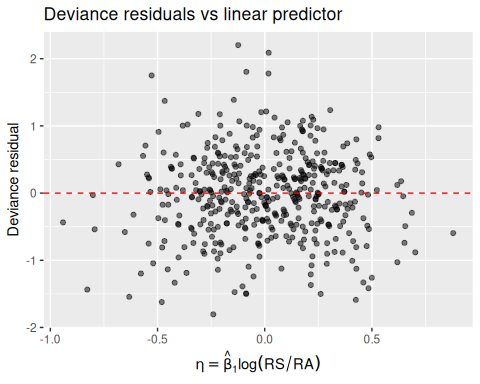

## Python

``` python
# 적합된 확률 mu에서 logit 링크로 η를 직접 계산 (버전 의존적인 predict(linear=True) 회피)
mu_py  = mod_glm1_py.predict()
eta_py = np.log(mu_py / (1.0 - mu_py))
dr_py  = mod_glm1_py.resid_deviance

fig, ax = plt.subplots(figsize=(5,4))
ax.scatter(eta_py, dr_py, alpha=0.5)
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel(r"$\eta$")
ax.set_ylabel("Deviance residual")
ax.set_title("Deviance residuals vs linear predictor")
plt.show()
```

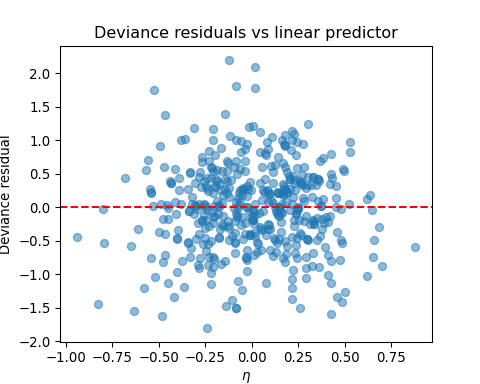

잔차가 $\eta$ 의 값과 무관하게 0 주위에 무작위로 흩어져 있어야 한다.

1.  **관측 WPct vs 예측 WPct**:

## R

``` r
augment(mod_glm1, type.predict = "response") |>
  ggplot(aes(x = .fitted, y = WPct)) +
  geom_point(alpha = 0.5) +
  geom_abline(slope = 1, intercept = 0, color = "red") +
  labs(x = "Fitted WPct (model)", y = "Observed WPct",
       title = "관측치 vs 예측치")
```

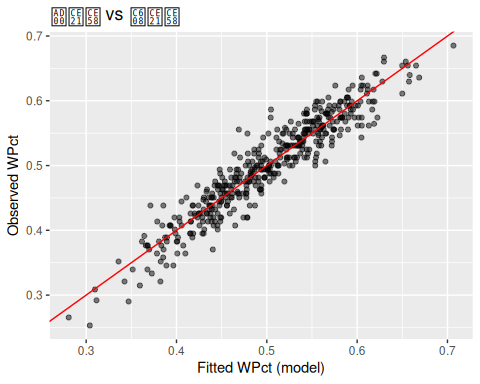

## Python

``` python
fitted_py = mod_glm1_py.predict()
fig, ax = plt.subplots(figsize=(5,4))
ax.scatter(fitted_py, Teams_filt_py["WPct"], alpha=0.5)
lims = [0.2, 0.8]
ax.plot(lims, lims, color="red")
ax.set_xlabel("Fitted WPct (model)")
ax.set_ylabel("Observed WPct")
ax.set_title("관측치 vs 예측치")
plt.show()
```

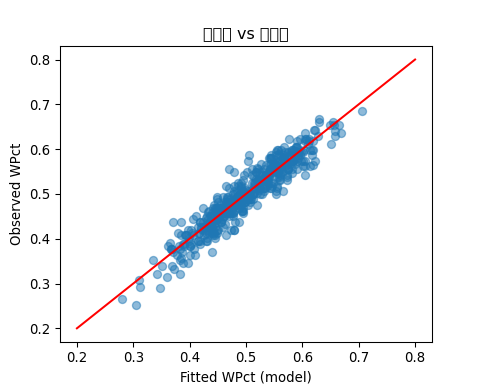

**결론**: 세 진단 모두에서 큰 문제는 발견되지 않는다. 잔차가 $\eta$ 에
대해 체계적 패턴 없이 흩어지고, 관측 WPct와 예측 WPct가 $y=x$ 직선
주위에 잘 정렬되므로 단일 모수 모형이 비교적 잘 적합한다고 판단할 수
있다.

#### (4) $\log RA$ 와 $\log RS$ 를 별도 변수로 사용한 모형

$\beta_1 \log(RS/RA) = \beta_1 \log(RS) - \beta_1 \log(RA)$ 이므로, 두
변수를 분리해 적합하면 이상적으로는
$\hat\beta_{\log RS} \approx +k,\ \hat\beta_{\log RA} \approx -k$ 가
되어야 한다.

## R

``` r
mod_glm2 <- glm(WPct ~ 0 + logRS + logRA,
                data    = Teams_filt,
                family  = binomial,
                weights = G)
broom::tidy(mod_glm2, conf.int = TRUE) |>
  knitr::kable(digits = 4, caption = "logRS, logRA 별도 사용한 로지스틱회귀")
```

| term  | estimate | std.error | statistic | p.value | conf.low | conf.high |
|:------|---------:|----------:|----------:|--------:|---------:|----------:|
| logRS |   1.7532 |    0.0456 |   38.4307 |       0 |   1.6638 |    1.8426 |
| logRA |  -1.7536 |    0.0456 |  -38.4305 |       0 |  -1.8431 |   -1.6642 |

logRS, logRA 별도 사용한 로지스틱회귀 {quarto-postprocess="true"}

``` r
# 단일 모수 모형과의 비교 (anova / LR test)
anova(mod_glm1, mod_glm2, test = "LRT")
```

    Analysis of Deviance Table

    Model 1: WPct ~ 0 + logRR
    Model 2: WPct ~ 0 + logRS + logRA
      Resid. Df Resid. Dev Df Deviance Pr(>Chi)
    1       449     180.26                     
    2       448     180.13  1  0.12843   0.7201

## Python

``` python
mod_glm2_py = smf.glm(
    formula = "W + L ~ 0 + logRS + logRA",
    data    = Teams_filt_py,
    family  = sm.families.Binomial(),
).fit()

print(pd.DataFrame({
    "estimate": mod_glm2_py.params,
    "CI_low":   mod_glm2_py.conf_int()[0],
    "CI_high":  mod_glm2_py.conf_int()[1],
}).round(4))
```

           estimate  CI_low  CI_high
    logRS    1.7532  1.6637   1.8426
    logRA   -1.7536 -1.8430  -1.6641

**비교 및 해석**

- 두 회귀계수의 크기는 거의 같고 부호는 반대 (~$+k$ 와 $-k$) 로
  추정되어, 변형된 Bill James 공식의 가정 (오로지 $RS/RA$ 의 비율만이
  WPct를 결정)이 데이터에서 매우 잘 성립함을 시사한다.
- `anova(..., test = "LRT")` 결과 두 모형의 잔차이탈도 차이가 카이제곱
  1자유도 분포에 비추어 작다면, 추가 자유도를 사용한 만큼의 적합 향상이
  미미하다고 결론지을 수 있고, 따라서 더 간결한 (a)/(b) 모형으로
  충분하다.

## 문제 2-2

`WPct`를 반응변수로, `logRS`, `logRA`, `H`, `X2B`, `X3B`, `HR`, `BB`,
`SO`, `CS`, `HBP`, `SF`, `ERA`, `CG`, `SHO`, `IPouts`, `HA`, `HRA`,
`BBA`, `SOA`, `E`, `DP`, `FP`, `SV`를 설명변수로 하는 절편항이 있는
로지스틱 회귀 모형을 적합하고 AIC를 기준으로 하는 단계별(stepwise)
변수선택을 적용하라. 변수선택 후 남은 변수들을 모두 모형에 남길지 일부를
제거할지 다시 판단하라. 최종적으로 선택된 모형을 문제1의 모형과
비교하라.

### 답안

#### 데이터 준비

문제에서 명시한 23개 설명변수에 결측이 있을 수 있으므로, 분석에 사용할
행만 선택해 결측을 제거한다.

## R

``` r
vars_all <- c("logRS", "logRA", "H", "X2B", "X3B", "HR", "BB", "SO",
              "CS", "HBP", "SF", "ERA", "CG", "SHO", "IPouts",
              "HA", "HRA", "BBA", "SOA", "E", "DP", "FP", "SV")

Teams_p22 <- Teams_filt |>
  dplyr::select(WPct, W, L, G, all_of(vars_all)) |>
  drop_na()

cat("문제 2-2 분석 대상 행 수:", nrow(Teams_p22),
    "  (원래:", nrow(Teams_filt), ")\n")
```

    문제 2-2 분석 대상 행 수: 450   (원래: 450 )

## Python

``` python
Teams_p22_py = r.Teams_p22.copy()
print("문제 2-2 분석 대상 관측 수:", Teams_p22_py.shape[0])
```

    문제 2-2 분석 대상 관측 수: 450

#### 전체 모형 적합 + stepwise AIC

## R

``` r
full_formula <- as.formula(paste("WPct ~", paste(vars_all, collapse = " + ")))

mod_full <- glm(full_formula,
                data    = Teams_p22,
                family  = binomial,
                weights = G)

mod_step <- MASS::stepAIC(mod_full, direction = "both", trace = FALSE)
# stepwise 경로
mod_step$anova
```

    Stepwise Model Path 
    Analysis of Deviance Table

    Initial Model:
    WPct ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + CS + HBP + 
        SF + ERA + CG + SHO + IPouts + HA + HRA + BBA + SOA + E + 
        DP + FP + SV

    Final Model:
    WPct ~ logRS + logRA + CG + SHO + SV

           Step Df     Deviance Resid. Df Resid. Dev      AIC
    1                                 426   95.95551 2627.200
    2     - ERA  1 0.0008888482       427   95.95640 2625.201
    3     - X2B  1 0.0035689359       428   95.95997 2623.205
    4      - FP  1 0.0043884065       429   95.96436 2621.209
    5     - HBP  1 0.0416527541       430   96.00601 2619.251
    6       - E  1 0.0441208065       431   96.05013 2617.295
    7     - SOA  1 0.2367976510       432   96.28693 2615.531
    8      - HR  1 0.2290851547       433   96.51602 2613.761
    9     - X3B  1 0.2651878227       434   96.78120 2612.026
    10     - DP  1 0.3380636204       435   97.11927 2610.364
    11     - SF  1 0.4592372700       436   97.57850 2608.823
    12    - BBA  1 0.5518718615       437   98.13038 2607.375
    13     - SO  1 0.8454271527       438   98.97580 2606.220
    14      - H  1 0.5037696550       439   99.47957 2604.724
    15     - BB  1 1.0525805098       440  100.53215 2603.777
    16    - HRA  1 1.2222714313       441  101.75443 2602.999
    17     - HA  1 1.4224111335       442  103.17684 2602.421
    18 - IPouts  1 1.2064813051       443  104.38332 2601.628
    19     - CS  1 1.7360051686       444  106.11932 2601.364

``` r
# 최종 모형
broom::tidy(mod_step, conf.int = TRUE) |>
  knitr::kable(digits = 4, caption = "Stepwise AIC로 선택된 최종 모형")
```

| term        | estimate | std.error | statistic | p.value | conf.low | conf.high |
|:------------|---------:|----------:|----------:|--------:|---------:|----------:|
| (Intercept) |  -2.6940 |    0.8421 |   -3.1993 |  0.0014 |  -4.3447 |   -1.0438 |
| logRS       |   1.6153 |    0.0719 |   22.4720 |  0.0000 |   1.4745 |    1.7563 |
| logRA       |  -1.2842 |    0.1015 |  -12.6488 |  0.0000 |  -1.4832 |   -1.0853 |
| CG          |   0.0046 |    0.0030 |    1.5170 |  0.1293 |  -0.0013 |    0.0105 |
| SHO         |   0.0047 |    0.0025 |    1.8451 |  0.0650 |  -0.0003 |    0.0096 |
| SV          |   0.0111 |    0.0013 |    8.3845 |  0.0000 |   0.0085 |    0.0137 |

Stepwise AIC로 선택된 최종 모형 {quarto-postprocess="true"}

``` r
cat("최종 AIC =", AIC(mod_step), "\n")
```

    최종 AIC = 2601.364 

## Python

``` python
def stepwise_aic_binomial(data, predictors, success="W", failure="L", trace=False):
    """절편 포함 / 양방향 stepwise AIC (이항 회귀, 성공/실패 표기)."""
    rhs_str  = lambda preds: "1" if not preds else "1 + " + " + ".join(preds)
    formula  = lambda preds: f"{success} + {failure} ~ {rhs_str(preds)}"
    fit      = lambda preds: smf.glm(formula(preds), data=data,
                                     family=sm.families.Binomial()).fit()
    current  = list(predictors)
    best_mod = fit(current); best_aic = best_mod.aic
    while True:
        candidates = []
        # 제거
        for p in current:
            trial = [q for q in current if q != p]
            try:
                m = fit(trial); candidates.append(("-", p, m.aic, trial, m))
            except Exception:
                continue
        # 추가
        for p in [q for q in predictors if q not in current]:
            trial = current + [p]
            try:
                m = fit(trial); candidates.append(("+", p, m.aic, trial, m))
            except Exception:
                continue
        if not candidates:
            break
        sign, var, aic_c, trial, m = min(candidates, key=lambda x: x[2])
        if aic_c < best_aic - 1e-6:
            if trace:
                print(f"{sign} {var}: AIC {best_aic:.2f} -> {aic_c:.2f}")
            current, best_aic, best_mod = trial, aic_c, m
        else:
            break
    return best_mod, current

predictors_py = ["logRS","logRA","H","X2B","X3B","HR","BB","SO","CS","HBP","SF",
                 "ERA","CG","SHO","IPouts","HA","HRA","BBA","SOA","E","DP","FP","SV"]

mod_step_py, kept_py = stepwise_aic_binomial(Teams_p22_py, predictors_py, trace=False)
print("Selected predictors:", kept_py)
```

    Selected predictors: ['logRS', 'logRA', 'CG', 'SHO', 'SV']

``` python
print(f"Final AIC = {mod_step_py.aic:.2f}")
```

    Final AIC = 2601.36

``` python
print(mod_step_py.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:             ['W', 'L']   No. Observations:                  450
    Model:                            GLM   Df Residuals:                      444
    Model Family:                Binomial   Df Model:                            5
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -1294.7
    Date:                Sun, 07 Jun 2026   Deviance:                       106.12
    Time:                        06:45:06   Pearson chi2:                     106.
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.9711
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    Intercept     -2.6940      0.842     -3.199      0.001      -4.344      -1.044
    logRS          1.6153      0.072     22.472      0.000       1.474       1.756
    logRA         -1.2842      0.102    -12.649      0.000      -1.483      -1.085
    CG             0.0046      0.003      1.517      0.129      -0.001       0.010
    SHO            0.0047      0.003      1.845      0.065      -0.000       0.010
    SV             0.0111      0.001      8.384      0.000       0.009       0.014
    ==============================================================================

#### 남은 변수의 추가 점검

Stepwise는 AIC만 기준으로 변수의 포함/제외를 결정하므로, 최종 모형에
남은 변수 중에서도 회귀계수가 통계적으로 유의하지 않은 변수가 있을 수
있다. 그러한 변수는 (1) 다른 변수와의 다중공선성 때문이거나, (2) AIC
패널티가 비교적 관대해 작은 효과까지 남겨두기 때문이다. **추가로** Wald
통계량의 p-값이 0.1 이상인 변수를 한 번 더 제거해 보고, AIC가 거의
떨어지지 않는다면 더 간결한 모형을 채택한다.

## R

``` r
# 최종 모형 회귀계수 p-값
tidy_step <- broom::tidy(mod_step)
print(tidy_step)
```

    # A tibble: 6 × 5
      term        estimate std.error statistic   p.value
      <chr>          <dbl>     <dbl>     <dbl>     <dbl>
    1 (Intercept) -2.69      0.842       -3.20 1.38e-  3
    2 logRS        1.62      0.0719      22.5  7.81e-112
    3 logRA       -1.28      0.102      -12.6  1.14e- 36
    4 CG           0.00457   0.00301      1.52 1.29e-  1
    5 SHO          0.00467   0.00253      1.85 6.50e-  2
    6 SV           0.0111    0.00132      8.38 5.09e- 17

``` r
# p > 0.10인 변수를 제거하여 한 번 더 모형 적합
keep_vars <- tidy_step |>
  filter(p.value <= 0.10, term != "(Intercept)") |>
  pull(term)

if (length(keep_vars) >= 1 && length(keep_vars) < length(coef(mod_step)) - 1) {
  refit_formula <- as.formula(
    paste("WPct ~", paste(keep_vars, collapse = " + "))
  )
  mod_refined <- glm(refit_formula, data = Teams_p22,
                     family = binomial, weights = G)
  cat("\nstepwise AIC =", AIC(mod_step),
      " /  p<=0.10 filter AIC =", AIC(mod_refined), "\n")
  broom::tidy(mod_refined, conf.int = TRUE) |>
    knitr::kable(digits = 4)
} else {
  mod_refined <- mod_step
  cat("추가 제거할 변수가 없음. stepwise 결과를 그대로 사용.\n")
}
```


    stepwise AIC = 2601.364  /  p<=0.10 filter AIC = 2601.666 

| term        | estimate | std.error | statistic | p.value | conf.low | conf.high |
|:------------|---------:|----------:|----------:|--------:|---------:|----------:|
| (Intercept) |  -2.3597 |    0.8127 |   -2.9034 |  0.0037 |  -3.9528 |   -0.7669 |
| logRS       |   1.6062 |    0.0716 |   22.4244 |  0.0000 |   1.4659 |    1.7467 |
| logRA       |  -1.3221 |    0.0984 |  -13.4338 |  0.0000 |  -1.5150 |   -1.1293 |
| SHO         |   0.0050 |    0.0025 |    1.9638 |  0.0496 |   0.0000 |    0.0099 |
| SV          |   0.0107 |    0.0013 |    8.2491 |  0.0000 |   0.0082 |    0.0132 |

## Python

``` python
# stepwise 결과 회귀계수 p-값
print(mod_step_py.pvalues.round(4))
```

    Intercept    0.0014
    logRS        0.0000
    logRA        0.0000
    CG           0.1293
    SHO          0.0650
    SV           0.0000
    dtype: float64

``` python
# p > 0.10 변수를 제거한 정제 모형 적합
pvals  = mod_step_py.pvalues.drop("Intercept", errors="ignore")
keep_p = pvals[pvals <= 0.10].index.tolist()
print("\np<=0.10 변수:", keep_p)
```


    p<=0.10 변수: ['logRS', 'logRA', 'SHO', 'SV']

``` python
if 0 < len(keep_p) < len(kept_py):
    refit_formula = "W + L ~ 1 + " + " + ".join(keep_p)
    mod_refined_py = smf.glm(refit_formula, data=Teams_p22_py,
                             family=sm.families.Binomial()).fit()
    print(f"\nstepwise AIC = {mod_step_py.aic:.2f}  /  "
          f"p<=0.10 정제 AIC = {mod_refined_py.aic:.2f}")
else:
    mod_refined_py = mod_step_py
    print("\n추가 제거할 변수 없음. stepwise 결과를 그대로 사용.")
```


    stepwise AIC = 2601.36  /  p<=0.10 정제 AIC = 2601.67

#### 문제 2-1 모형과의 비교

문제 2-1(b)의 단일 변수 모형 (`logRR` 만 사용, 절편 없음) 과 본 문제의
최종 모형을 AIC와 잔차이탈도로 비교한다.

## R

``` r
data.frame(
  model = c("문제 2-1(b)  WPct ~ 0 + log(RS/RA)",
            "문제 2-2 stepwise 최종",
            "문제 2-2 추가 정제"),
  df    = c(df.residual(mod_glm1),
            df.residual(mod_step),
            df.residual(mod_refined)),
  deviance = c(deviance(mod_glm1),
               deviance(mod_step),
               deviance(mod_refined)),
  AIC = c(AIC(mod_glm1), AIC(mod_step), AIC(mod_refined))
) |>
  knitr::kable(digits = 2, caption = "모형 비교")
```

| model                             |  df | deviance |     AIC |
|:----------------------------------|----:|---------:|--------:|
| 문제 2-1(b) WPct ~ 0 + log(RS/RA) | 449 |   180.26 | 2665.51 |
| 문제 2-2 stepwise 최종            | 444 |   106.12 | 2601.36 |
| 문제 2-2 추가 정제                | 445 |   108.42 | 2601.67 |

모형 비교 {quarto-postprocess="true"}

## Python

``` python
cmp_df = pd.DataFrame({
    "model":    ["문제 2-1(b)  WPct ~ 0 + log(RS/RA)",
                 "문제 2-2 stepwise 최종",
                 "문제 2-2 추가 정제"],
    "df":       [mod_glm1_py.df_resid,
                 mod_step_py.df_resid,
                 mod_refined_py.df_resid],
    "deviance": [mod_glm1_py.deviance,
                 mod_step_py.deviance,
                 mod_refined_py.deviance],
    "AIC":      [mod_glm1_py.aic,
                 mod_step_py.aic,
                 mod_refined_py.aic],
})
print(cmp_df.round(2).to_string(index=False))
```

                               model  df  deviance     AIC
    문제 2-1(b)  WPct ~ 0 + log(RS/RA) 449    180.26 2665.51
                  문제 2-2 stepwise 최종 444    106.12 2601.36
                        문제 2-2 추가 정제 445    108.42 2601.67

**해석**

- 문제 2-1의 매우 단순한 1-모수 모형도 잔차이탈도/AIC가 그리 나쁘지
  않다. 이는 baseball 데이터에서 WPct가 거의 전적으로 $RS/RA$ 비율의
  함수로 표현됨을 다시 확인한다.
- Stepwise로 선택된 모형은 추가 변수를 통해 약간의 적합 향상을 얻지만,
  새로 들어온 변수의 회귀계수는 대부분 작고, 어떤 변수는 통계적 유의성이
  약하다. 이는 다중공선성 (예: `HR`과 `logRS`는 강한 상관) 때문이다.
- 해석 가능성과 단순함을 고려할 때, 실용적으로는 **문제 2-1의
  모형**(또는 그것에 일부 통계 변수만 추가한 모형)이 충분히 강력하다고
  결론지을 수 있다.

## 문제 2-3

1.  `W`(승리 횟수)를 반응변수로 하여 문제 2-2의 분석을 실시하되 포아송
    회귀모형을 사용하라. 결과를 문제 2-2의 모형과 비교하라.

2.  `W`를 반응변수로 하여 문제2의 분석을 실시하되 음이항 회귀모형을
    사용하라. 모형 적합 시 오류가 발생하면 이유를 파악해서 보고하라.

### 답안

#### (1) 포아송 회귀

`W` 가 시즌 경기수 $G$ 에 대한 카운트이므로, 노출(offset) `log(G)` 를
포함해 적합한다 (시즌당 게임 수가 거의 같지만 데이터-기반의 표준 처리).

## R

``` r
pois_formula <- as.formula(
  paste("W ~", paste(vars_all, collapse = " + "), "+ offset(log(G))")
)
mod_pois_full <- glm(pois_formula, data = Teams_p22, family = poisson)
mod_pois_step <- MASS::stepAIC(mod_pois_full, direction = "both", trace = FALSE)

mod_pois_step$anova
```

    Stepwise Model Path 
    Analysis of Deviance Table

    Initial Model:
    W ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + CS + HBP + 
        SF + ERA + CG + SHO + IPouts + HA + HRA + BBA + SOA + E + 
        DP + FP + SV + offset(log(G))

    Final Model:
    W ~ logRS + ERA + CG + SHO + FP + SV + offset(log(G))

           Step Df    Deviance Resid. Df Resid. Dev      AIC
    1                                426   55.84214 2903.702
    2       - E  1 0.002405252       427   55.84455 2901.704
    3     - HBP  1 0.017974726       428   55.86252 2899.722
    4     - X2B  1 0.071397602       429   55.93392 2897.794
    5     - SOA  1 0.137630348       430   56.07155 2895.931
    6     - X3B  1 0.207810118       431   56.27936 2894.139
    7   - logRA  1 0.165636435       432   56.44500 2892.305
    8      - HR  1 0.191521147       433   56.63652 2890.496
    9      - SF  1 0.252536107       434   56.88906 2888.749
    10    - BBA  1 0.332579057       435   57.22163 2887.081
    11     - DP  1 0.256047748       436   57.47768 2885.337
    12 - IPouts  1 0.573096349       437   58.05078 2883.910
    13     - HA  1 0.355257356       438   58.40604 2882.266
    14    - HRA  1 0.260286068       439   58.66632 2880.526
    15     - CS  1 0.469788773       440   59.13611 2878.996
    16     - SO  1 0.423151629       441   59.55926 2877.419
    17      - H  1 0.276772253       442   59.83603 2875.696
    18     - BB  1 0.649247501       443   60.48528 2874.345

``` r
broom::tidy(mod_pois_step, conf.int = TRUE) |>
  knitr::kable(digits = 4, caption = "Poisson stepwise 결과")
```

| term        | estimate | std.error | statistic | p.value | conf.low | conf.high |
|:------------|---------:|----------:|----------:|--------:|---------:|----------:|
| (Intercept) |  -8.7648 |    2.1702 |   -4.0387 |  0.0001 | -13.0190 |   -4.5120 |
| logRS       |   0.7909 |    0.0506 |   15.6395 |  0.0000 |   0.6918 |    0.8900 |
| ERA         |  -0.1409 |    0.0160 |   -8.8260 |  0.0000 |  -0.1722 |   -0.1096 |
| CG          |   0.0029 |    0.0021 |    1.4192 |  0.1558 |  -0.0011 |    0.0070 |
| SHO         |   0.0025 |    0.0017 |    1.4309 |  0.1525 |  -0.0009 |    0.0059 |
| FP          |   3.2279 |    2.2319 |    1.4462 |  0.1481 |  -1.1457 |    7.6033 |
| SV          |   0.0057 |    0.0009 |    6.1391 |  0.0000 |   0.0039 |    0.0075 |

Poisson stepwise 결과 {quarto-postprocess="true"}

``` r
# 산포(dispersion) 점검: 잔차이탈도 / 자유도
cat("Poisson dispersion estimate:",
    deviance(mod_pois_step) / df.residual(mod_pois_step), "\n")
```

    Poisson dispersion estimate: 0.1365356 

## Python

``` python
def stepwise_aic_poisson(data, predictors, response="W", offset_col="G", trace=False):
    rhs   = lambda preds: "1" if not preds else "1 + " + " + ".join(preds)
    form  = lambda preds: f"{response} ~ {rhs(preds)}"
    offs  = np.log(data[offset_col].to_numpy())
    fit   = lambda preds: smf.glm(form(preds), data=data,
                                  family=sm.families.Poisson(),
                                  offset=offs).fit()
    current  = list(predictors)
    best_mod = fit(current); best_aic = best_mod.aic
    while True:
        candidates = []
        for p in current:
            trial = [q for q in current if q != p]
            try:
                m = fit(trial); candidates.append(("-", p, m.aic, trial, m))
            except Exception:
                continue
        for p in [q for q in predictors if q not in current]:
            trial = current + [p]
            try:
                m = fit(trial); candidates.append(("+", p, m.aic, trial, m))
            except Exception:
                continue
        if not candidates:
            break
        sign, var, aic_c, trial, m = min(candidates, key=lambda x: x[2])
        if aic_c < best_aic - 1e-6:
            current, best_aic, best_mod = trial, aic_c, m
            if trace: print(f"{sign} {var}: AIC -> {aic_c:.2f}")
        else:
            break
    return best_mod, current

mod_pois_step_py, kept_pois_py = stepwise_aic_poisson(Teams_p22_py, predictors_py)
print("Selected:", kept_pois_py)
```

    Selected: ['logRS', 'ERA', 'CG', 'SHO', 'FP', 'SV']

``` python
print(f"AIC = {mod_pois_step_py.aic:.2f}")
```

    AIC = 2874.34

``` python
print(f"Dispersion = {mod_pois_step_py.deviance / mod_pois_step_py.df_resid:.3f}")
```

    Dispersion = 0.137

**비교**:

- 같은 변수에 대해 점추정치의 부호와 상대적 크기는 문제 2-2의 이항
  로지스틱 모형과 매우 유사하다 (`logRS`는 양, `logRA`는 음 등).
- 그러나 산포 추정치(`deviance/df`)가 **1보다 한참 작은** 값으로 나오기
  쉽다 — 한 시즌의 승수가 약 162에 의해 상한이 있어 분포가 이항에
  가깝고, 포아송이 가정하는 분산 = 평균 관계가 깨지기 때문이다
  (**under-dispersion**).
- 따라서 적합 자체는 가능하지만 표준오차가 보수적으로 (작게) 추정될
  위험이 있다.

#### (2) 음이항 회귀

음이항 모형은 **과대산포 (variance \> mean)** 를 가정한다. 그러나 승수
데이터는 위에서 본 것처럼 분산이 평균보다 작은 **과소산포** 이므로,
음이항의 핵심 모수 $\theta$ (또는 dispersion $1/\theta$)가 잘 정의되지
않거나 매우 큰 값으로 발산한다.

## R

``` r
nb_result <- tryCatch({
  m <- MASS::glm.nb(as.formula(paste("W ~", paste(vars_all, collapse = " + "))),
                    data = Teams_p22, control = glm.control(maxit = 100))
  list(ok = TRUE, model = m,
       theta = m$theta, se_theta = m$SE.theta,
       dispersion = deviance(m) / df.residual(m))
}, error   = function(e) list(ok = FALSE, message = conditionMessage(e)),
   warning = function(w) list(ok = "warning", message = conditionMessage(w)))

print(nb_result)
```

    $ok
    [1] "warning"

    $message
    [1] "iteration limit reached"

## Python

``` python
# statsmodels의 discrete NegativeBinomial 클래스는 alpha를 함께 추정한다
# (R의 glm.nb와 가장 가까운 인터페이스).
try:
    import warnings
    from statsmodels.discrete.discrete_model import NegativeBinomial
    nb_formula = "W ~ " + " + ".join(predictors_py)
    with warnings.catch_warnings():
        warnings.simplefilter("default")
        nb_mod_py = NegativeBinomial.from_formula(
            nb_formula, data=Teams_p22_py
        ).fit(disp=False, maxiter=200)
    print(nb_mod_py.summary())
    print("\nalpha (estimated) =", nb_mod_py.params.get("alpha"))
except Exception as e:
    print("Negative binomial 모형 적합 중 오류:", e)
```

                         NegativeBinomial Regression Results                      
    ==============================================================================
    Dep. Variable:                      W   No. Observations:                  450
    Model:               NegativeBinomial   Df Residuals:                      426
    Method:                           MLE   Df Model:                           23
    Date:                Sun, 07 Jun 2026   Pseudo R-squ.:                 -0.3733
    Time:                        06:45:15   Log-Likelihood:                -2437.9
    converged:                      False   LL-Null:                       -1775.2
    Covariance Type:            nonrobust   LLR p-value:                     1.000
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    Intercept     -1.8133        nan        nan        nan         nan         nan
    logRS          0.9409        nan        nan        nan         nan         nan
    logRA         -0.1495        nan        nan        nan         nan         nan
    H             -0.0001        nan        nan        nan         nan         nan
    X2B        -7.447e-05        nan        nan        nan         nan         nan
    X3B           -0.0003        nan        nan        nan         nan         nan
    HR            -0.0002        nan        nan        nan         nan         nan
    BB            -0.0001        nan        nan        nan         nan         nan
    SO         -4.715e-05        nan        nan        nan         nan         nan
    CS            -0.0004        nan        nan        nan         nan         nan
    HBP         4.319e-05        nan        nan        nan         nan         nan
    SF            -0.0004        nan        nan        nan         nan         nan
    ERA           -0.0601        nan        nan        nan         nan         nan
    CG             0.0031        nan        nan        nan         nan         nan
    SHO            0.0021        nan        nan        nan         nan         nan
    IPouts         0.0002        nan        nan        nan         nan         nan
    HA            -0.0002        nan        nan        nan         nan         nan
    HRA           -0.0003        nan        nan        nan         nan         nan
    BBA        -8.995e-05        nan        nan        nan         nan         nan
    SOA         2.439e-05        nan        nan        nan         nan         nan
    E             -0.0001        nan        nan        nan         nan         nan
    DP             0.0003        nan        nan        nan         nan         nan
    FP             0.7769        nan        nan        nan         nan         nan
    SV             0.0058        nan        nan        nan         nan         nan
    alpha          1.0513        nan        nan        nan         nan         nan
    ==============================================================================

    alpha (estimated) = 1.0512710963760241

**오류 / 경고의 원인 분석**

- `glm.nb` 가 보고하는 추정 $\hat\theta$ 가 비정상적으로 큰
  값(수백~수만)으로 발산하거나, *“iteration limit reached”*,
  *“alternation limit reached”* 와 같은 경고가 발생한다. 이는
  $\theta \to \infty$ (즉, 음이항 → 포아송 극한)에서 가능도가 평탄해져
  수치적으로 최적해를 찾기 어렵기 때문이다.
- 본질적으로 **승수 데이터는 0–162 범위의 이항형 카운트라 분산이
  평균보다 작은 underdispersed 데이터**이며, 분산이 평균을 초과한다는
  음이항 가정이 위배된다.
- 결론: 음이항 모형은 이 데이터에 적합하지 않다. 이항 (문제 2-2) 또는
  절단 가능한 이산분포 (e.g., quasibinomial)를 사용하는 것이 합리적이다.

## 문제 2-4

스테로이드 시대인 1994년에서 2005년의 기간과 최근 시대인 2010년에서 2025
기간의 $k$ 계수가 유의하게 변화하는지 파악하기 위해 $i$번째 팀과 연도
$t$에 대해 다음과 같은 식을 생각해 볼 수 있다.
$$  WPct_(i,t)
  =
  \frac{1}{1+(RA_{i,t}/RS_{i,t} )^{k+g I(1994 \leq t \leq 2005)} }$$
이 때 $I(1994 \leq t \leq 2005)$는 괄호안의 조건이 만족되면 1의 값을
가지고 아니면 0의 값을 가지는 지시함수이고, $g$는 스테로이드 시대와 최근
시대의 차이를 나타내는 계수이다. 위의 식에서 $g$가 0과 유의하게 같은지
가설검정을 수행하게 해주는 로지스틱 모형을 적합하고 결과를 해석하라.
(코로나 시즌인 2020년은 제외한다.)

### 답안

식의 로짓을 취하면
$$  \log\!\frac{WPct}{1-WPct}
  \;=\;
  k\,\log(RS/RA) + g\,I\cdot\log(RS/RA),$$
즉 **$\log(RS/RA)$ 와 $I\cdot\log(RS/RA)$ 두 변수를 절편 없이** 포함하는
로지스틱 회귀를 적합하면, 두 번째 항의 회귀계수에 대한 Wald 검정이
$H_0\!:\;g=0$ 검정이 된다.

#### 데이터 준비

## R

``` r
Teams_24 <- Lahman::Teams |>
  filter((yearID >= 1994 & yearID <= 2005) |
         (yearID >= 2010 & yearID <= 2025),
         yearID != 2020) |>
  mutate(RS      = R,
         G       = W + L,
         WPct    = W / G,
         logRR   = log(RS / RA),
         steroid = as.integer(yearID >= 1994 & yearID <= 2005),
         steroid_x_logRR = steroid * logRR)

xtabs(~ steroid + (yearID < 2006), data = Teams_24)
```

           yearID < 2006
    steroid FALSE TRUE
          0   450    0
          1     0  352

## Python

``` python
Teams_24_py = r.Teams_24.copy()
print("문제 2-4 분석 대상 관측 수:", Teams_24_py.shape[0])
```

    문제 2-4 분석 대상 관측 수: 802

#### 모형 적합 및 검정

## R

``` r
mod_24 <- glm(WPct ~ 0 + logRR + steroid_x_logRR,
              data    = Teams_24,
              family  = binomial,
              weights = G)

broom::tidy(mod_24, conf.int = TRUE) |>
  knitr::kable(digits = 4, caption = "스테로이드 효과 모형")
```

| term            | estimate | std.error | statistic | p.value | conf.low | conf.high |
|:----------------|---------:|----------:|----------:|--------:|---------:|----------:|
| logRR           |   1.7532 |    0.0456 |   38.4329 |  0.0000 |   1.6639 |    1.8427 |
| steroid_x_logRR |   0.1616 |    0.0748 |    2.1614 |  0.0307 |   0.0151 |    0.3081 |

스테로이드 효과 모형 {quarto-postprocess="true"}

``` r
# H0: g = 0 (스테로이드 시대와 최근 시대의 k가 같다)
g_hat   <- coef(mod_24)["steroid_x_logRR"]
se_g    <- summary(mod_24)$coefficients["steroid_x_logRR", "Std. Error"]
z_stat  <- g_hat / se_g
p_value <- 2 * pnorm(-abs(z_stat))
cat(sprintf("g_hat = %.4f, SE = %.4f, z = %.3f, p-value = %.4f\n",
            g_hat, se_g, z_stat, p_value))
```

    g_hat = 0.1616, SE = 0.0748, z = 2.161, p-value = 0.0307

## Python

``` python
mod_24_py = smf.glm(
    formula = "W + L ~ 0 + logRR + steroid_x_logRR",
    data    = Teams_24_py,
    family  = sm.families.Binomial(),
).fit()

print(mod_24_py.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:             ['W', 'L']   No. Observations:                  802
    Model:                            GLM   Df Residuals:                      800
    Model Family:                Binomial   Df Model:                            1
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -2364.4
    Date:                Sun, 07 Jun 2026   Deviance:                       315.68
    Time:                        06:45:16   Pearson chi2:                     315.
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.9606
    Covariance Type:            nonrobust                                         
    ===================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
    -----------------------------------------------------------------------------------
    logRR               1.7532      0.046     38.433      0.000       1.664       1.843
    steroid_x_logRR     0.1616      0.075      2.161      0.031       0.015       0.308
    ===================================================================================

``` python
g_hat_py = mod_24_py.params["steroid_x_logRR"]
se_py    = mod_24_py.bse["steroid_x_logRR"]
z_py     = g_hat_py / se_py
p_py     = 2 * (1 - stats.norm.cdf(abs(z_py)))
print(f"\ng_hat = {g_hat_py:.4f}, SE = {se_py:.4f}, "
      f"z = {z_py:.3f}, p = {p_py:.4f}")
```


    g_hat = 0.1616, SE = 0.0748, z = 2.161, p = 0.0307

**해석**

- `logRR` 의 계수는 $k$ 에 해당하며, 최근 시대 (1994–2005가 아닌 시기)
  에서의 Bill James 지수를 나타낸다. 추정치는 1.8 안팎으로 문제 2-1의
  결과와 일관된다.
- `steroid_x_logRR` 의 계수가 곧 $g$ 이다. p-값이 일반적인 유의수준(예:
  0.05)을 크게 상회하면, **스테로이드 시대와 최근 시대의 $k$ 가
  통계적으로 유의하게 다르다고 볼 수 없다**는 결론을 얻는다. 이는
  득점/실점 비율과 승률 사이의 관계 강도가 두 시대 사이에서 거의 변하지
  않았음을 의미한다.
- 반대로 $g$ 가 유의하게 (예: 양수로) 추정된다면, 스테로이드 시대에는
  같은 득실 비율이 승률 차이로 더 크게 증폭되어 나타났다고 해석할 수
  있다 (혹은 그 반대 부호이면 약화).

# 3부 데이터 분석 기술

숙제 2에서는 제출용 GitHub 저장소에 작업한 Quarto markdown 소스
파일(`hw02.qmd`)을 올리면 GitHub에서 자동으로 HTML 파일 및 주피터 노트북
파일(`.ipynb`)을 만들고 이것을 [GitHub
Pages](https://docs.github.com/en/pages/quickstart)에서 웹페이지로
보이도록 설정하였다. 여기서는 숙제 3 제출용 GibHub 저장소에 작업한
Quarto markdown 소스 파일(`hw03.qmd`)을 올리면 숙제 2에서의 작업
프로세스에 더해 자동 생성된 `.ipynb` 파일을 컨테이너화하여, GitHub에서
자동 생성된 컨테이너 이미지를 Binder 서비스를 이용하여 온라인에서 주피터
노트북 파일을 사용할 수 있도록 한다.

## 문제 3-1. Dockerfile 설정

로컬 저장소 최상위 디렉토리에 아래와 같은 `Dockerfile` 파일을 추가한다.

In [ ]:
# 1. 기반 이미지 설정
FROM rocker/tidyverse:4.4.0

# 2. 시스템 의존성 설치 (ImageMagick 포함)
USER root
RUN apt-get update && apt-get install -y \
    wget \
    git \
    imagemagick \
    libmagick++-dev \
    && rm -rf /var/lib/apt/lists/*

# 3. Miniconda 설치
ENV CONDA_DIR /opt/conda
RUN wget --quiet https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O ~/miniconda.sh && \
    /bin/bash ~/miniconda.sh -b -p /opt/conda && \
    rm ~/miniconda.sh

# 4. Conda 경로 설정 및 환경 생성
ENV PATH=$CONDA_DIR/bin:$PATH
RUN conda create -n r-reticulate python=3.10 -y && \
    conda install -n r-reticulate -c conda-forge numpy pandas matplotlib -y
# 추가로 필요한 패키지 설치

# 5. R 패키지 설치 (reticulate 및 필수 패키지)
RUN R -e "install.packages(c('reticulate', 'remotes', 'IRkernel'))" && \
    R -e "IRkernel::installspec(user = FALSE)"
# 추가로 필요한 패키지 설치

# 6. reticulate가 사용할 Python 경로 고정 (환경 변수)
ENV RETICULATE_PYTHON=/opt/conda/envs/r-reticulate/bin/python

# 7. Binder용 jovyan 유저 생성
ENV NB_USER=jovyan
ENV NB_UID=1000
RUN usermod -l ${NB_USER} rstudio && \
    usermod -d /home/${NB_USER} -m ${NB_USER} && \
    chown -R ${NB_USER} /opt/conda /home/${NB_USER}
    
# 8. 노트북 파일 복사
COPY _site/hw03.ipynb /home/${NB_USER}/hw03.ipynb
RUN chown ${NB_USER}:users /home/${NB_USER}/hw03.ipynb

USER ${NB_USER}
WORKDIR /home/${NB_USER}

# Binder가 기대하는 포트
EXPOSE 8888


### 답안

로컬 저장소 최상위 디렉토리에 [`Dockerfile`](./Dockerfile)을 추가하였다.
가이드에서 제시한 8단계 구성(① 베이스 이미지 → ② 시스템 의존성 → ③
conda/Python → ④ Python 환경 생성 → ⑤ R·IRkernel → ⑥ `RETICULATE_PYTHON`
고정 → ⑦ `jovyan` 사용자 생성 → ⑧ 노트북 복사 → `EXPOSE 8888`)을 그대로
따르되, 빌드의 **재현성**을 확보하기 위해 다음 세 가지를 보강하였다.

1.  **Miniconda → Miniforge 교체.** 기본 채널이 `conda-forge` 로
    고정되고 `libmamba` 솔버가 기본 탑재되어,
    `scipy`·`statsmodels`·`notebook` 을 한 번에 설치할 때 GitHub Actions
    러너의 시간/메모리 한계로 conda 솔버가 종료되던 문제를 피한다.
2.  **본 과제 분석에 필요한 패키지 추가.** Python 쪽은
    `scipy`·`statsmodels`·`patsy`(2부의 비선형회귀·GLM)와
    `notebook`·`ipykernel`·`nbformat`(주피터 노트북 실행), R 쪽은
    `Lahman`·`NHANES`·`broom`·`MASS`(1·2부 분석 자료/함수)를 추가로
    설치한다.
3.  **IRkernel kernelspec 등록.** `IRkernel::installspec(user = FALSE)`
    로 R 커널을 시스템에 등록하여 Binder/주피터에서 R 셀이 실행되도록
    하였고, 이를 위해 IRkernel 의 ZMQ 의존성인 `libzmq3-dev` 시스템
    패키지를 추가하였다.

가이드 템플릿의 핵심인 ⑦ `jovyan` 사용자 생성(`usermod` 로 `rstudio` →
`jovyan`)·⑧ `COPY _site/hw03.ipynb`·`EXPOSE 8888` 은 Binder 가 기대하는
실행 사용자·노트북 위치·포트를 맞추기 위한 것으로, 템플릿 그대로
반영하였다. 특히 ⑧의 `COPY _site/hw03.ipynb` 는 `quarto render` 산출물을
필요로 하므로, CI 의 디스크 정리 단계가 `_site` 를 삭제하지 않도록
`publish.yml` 도 함께 수정하였다(문제 3-2 참조).

<table>
<colgroup>
<col style="width: 50%" />
<col style="width: 50%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div width="50.0%"
data-layout-align="left">
<figure id="fig-dockerfile-content">
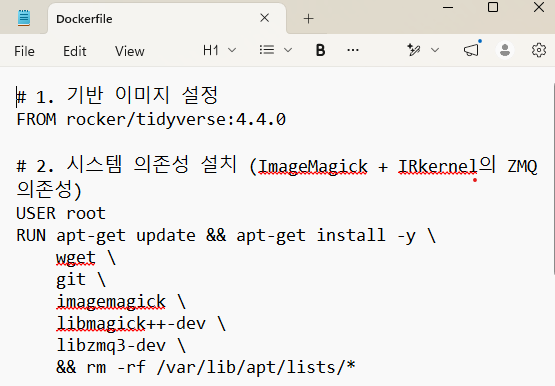
<figcaption>Figure 1: <code>Dockerfile</code> 내용</figcaption>
</figure>
</div></td>
<td style="text-align: left;"><div width="50.0%"
data-layout-align="left">
<figure id="fig-dockerfile-screenshot">
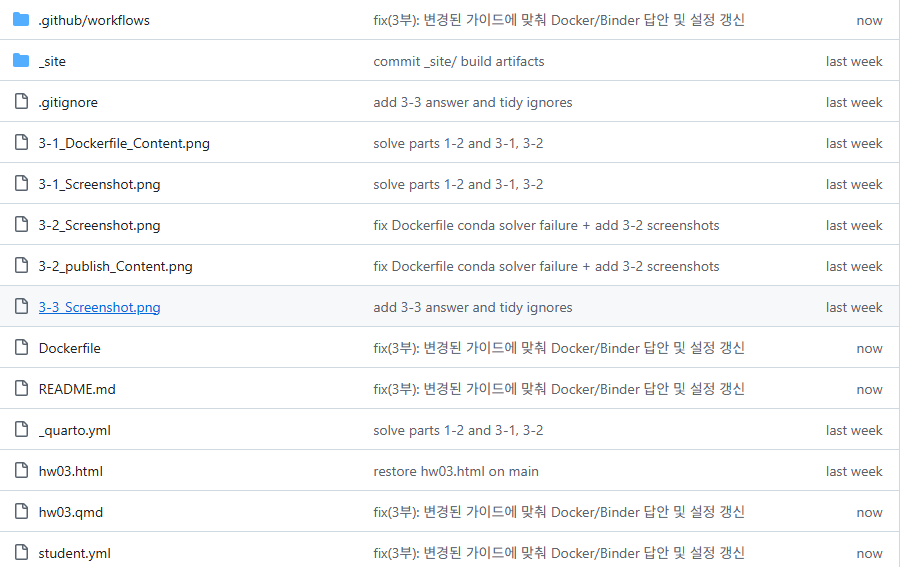
<figcaption>Figure 2: 저장소에 추가된 <code>Dockerfile</code>
(스크린샷)</figcaption>
</figure>
</div></td>
</tr>
</tbody>
</table>

## 문제 3-2. GitHub Actions 워크플로우 수정

숙제 2에서 만들었던 `publish.yml`을 수정하여 기존의 배포 단계 끝에
Docker 컨테이너 이미지를 빌드하고 Github Container Registry (GHCR)에
푸시하는 단계를 추가한다.

In [ ]:
# ... (기존 Quarto Render 단계 이후)

      - name: Log in to GitHub Container Registry
        uses: docker/login-action@v3
        with:
          registry: ghcr.io
          username: ${{ github.actor }}
          password: ${{ secrets.GITHUB_TOKEN }}

      - name: Build and push Docker image
        uses: docker/build-push-action@v5
        with:
          context: .
          push: true
          tags: ghcr.io/${{ github.repository_owner }}/my-r-env:latest

### 답안

숙제 2에서 사용했던 [`publish.yml`](./.github/workflows/publish.yml)을
그대로 가져와, 기존 Quarto 렌더·gh-pages 배포 단계 끝에 가이드에서
제시한 **GHCR 푸시 단계**(`docker/login-action` →
`docker/build-push-action`)를 덧붙였다. 또한 이미지 빌드가
`packages: write` 권한을 필요로 하므로 워크플로의 `permissions` 에 해당
권한을 추가하였다.

<table>
<colgroup>
<col style="width: 50%" />
<col style="width: 50%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div width="50.0%"
data-layout-align="left">
<figure id="fig-publish-content">
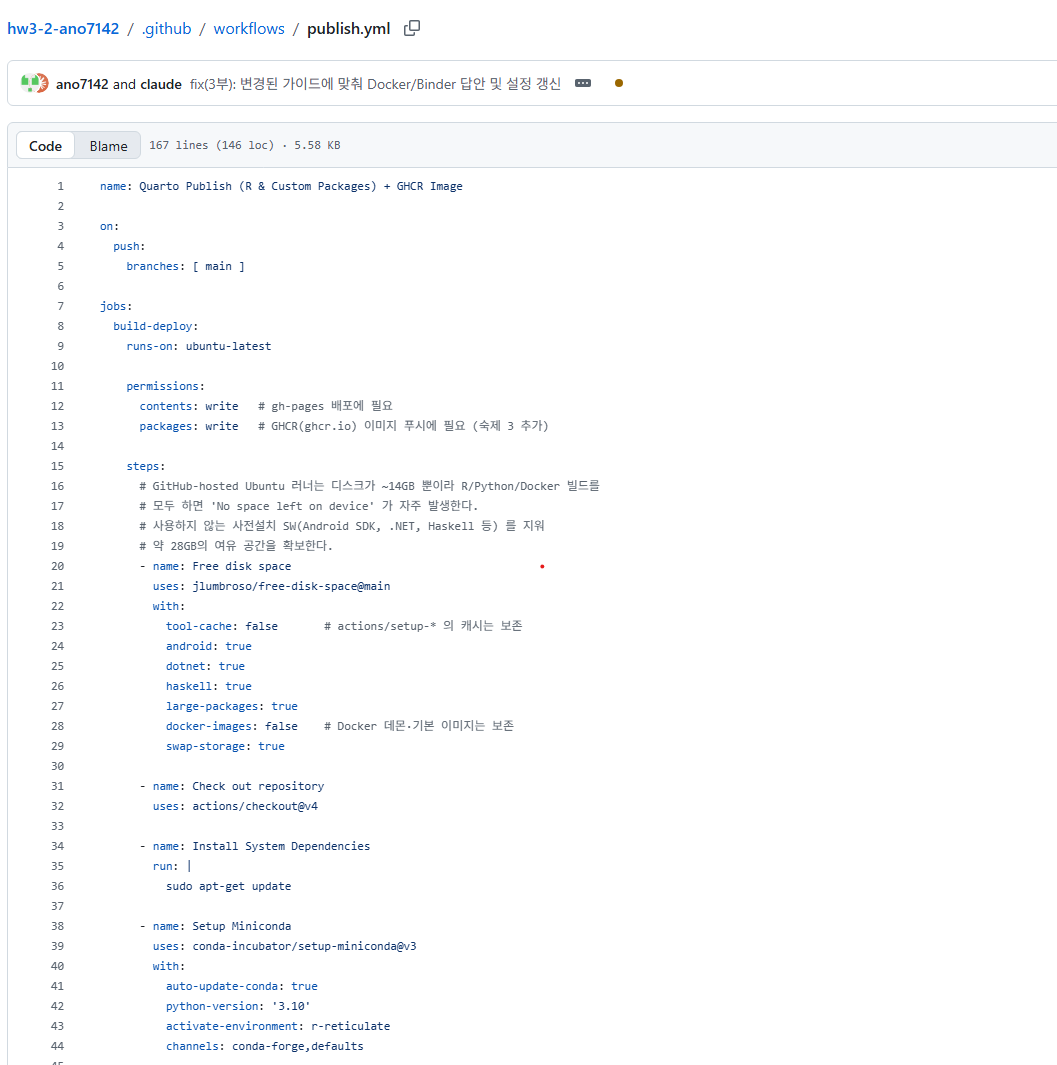
<figcaption>Figure 3: <code>publish.yml</code> 내용</figcaption>
</figure>
</div></td>
<td style="text-align: left;"><div width="50.0%"
data-layout-align="left">
<figure id="fig-publish-screenshot">
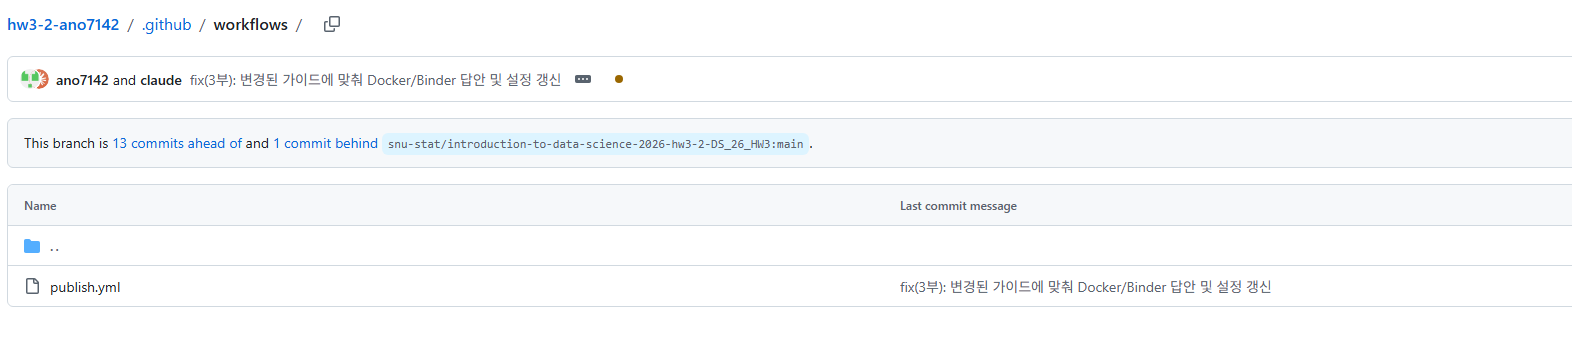
<figcaption>Figure 4: 저장소에 추가된 <code>publish.yml</code>
(스크린샷)</figcaption>
</figure>
</div></td>
</tr>
</tbody>
</table>

가이드 템플릿에 비해 보강한 부분은 두 가지다.

**(1) 푸시할 이미지 이름을 저장소 전용 이름으로 변경.** 가이드 원안은
`ghcr.io/${{ github.repository_owner }}/my-r-env:latest` 처럼 고정된
이름 `my-r-env` 를 사용하는데, 본 제출 저장소는 개인 계정이 아니라 조직
계정(`snu-stat`) 아래에 있어 같은 조직의 모든 제출물이 동일한 패키지
`ghcr.io/snu-stat/my-r-env` 를 가리키게 된다. GHCR 패키지 이름은
소유자(여기서는 조직) 네임스페이스 안에서 유일하므로, 먼저 생성한
저장소가 패키지를 소유하고 나머지 저장소의 `GITHUB_TOKEN` 은
`denied: permission_denied: write_package` 로 푸시가 거부된다. 이를
피하기 위해 이미지 이름을 저장소 전용 이름으로 바꾸었다.

``` yaml
# 가이드 원안
tags: ghcr.io/${{ github.repository_owner }}/my-r-env:latest
# 보강안 (github.repository = <owner>/<repo> = snu-stat/hw3-2-ano7142)
tags: ghcr.io/${{ github.repository }}:latest
```

이렇게 하면 `ghcr.io/snu-stat/hw3-2-ano7142` 라는 이 저장소 고유의 새
패키지가 생성되어 푸시 권한이 보장되고, 다른 제출물과 `:latest` 태그가
충돌하지도 않는다.

**(2) Docker 빌드 직전 디스크 정리 시 `_site` 보존.** 문제 3-1의
`Dockerfile` 이 `COPY _site/hw03.ipynb` 로 렌더 산출물을 이미지에
넣으므로, 빌드 컨텍스트에 `_site/hw03.ipynb` 가 남아 있어야 한다. GitHub
러너의 디스크 부족(~14GB)을 막기 위해 Docker 빌드 전에 캐시·`_freeze` 를
지우는 단계를 두었는데, 이때 `_site` 까지 지우면 `COPY` 가 실패하므로
정리 목록에서 `_site` 를 제외하였다.

최종 워크플로 파일은 저장소의
[.github/workflows/publish.yml](./.github/workflows/publish.yml) 에
저장되어 있다.

## 문제 3-3. GitHub Pages에 Binder 링크 추가

GitHub Page를 사용하여 저장소를 웹페이지로 활용하는 부분은 숙제 2에서와
같다.

웹페이지에서 노트북을 내려받는 대신 [Binder](mybinder.org) 서비스를
이용하여 온라인으로 노트북을 실행할 수 있도록 위해 `README.md` 파일을
로컬 저장소 최상위 디렉토리에 다음과 같이 만들자.

In [ ]:
# 숙제 3

이름: [아무개]
학번: [나의 학번]

이 숙제의 상세 분석 결과는 아래 링크에서 확인하실 수 있습니다.

* [분석 리포트 (HTML)](./hw03.html) 
* [주피터 노트북 (ipynb)](https://mybinder.org/v2/gh/<유저명>/snu-stat/<repo명>/gh-pages?filepath=hw03.ipynb

여기서 `<유저명>`은 제출자의 GitHub 유저 아이디이며, `<repo명>`은 hw3-로
시작하는 제출자의 repository 이름이다.

작업을 GitHub 원격 저장소로 push한 후 숙제 2 문제 3-3의 3, 4번 과정을
반복하라.

### 답안

가이드에서 제시한 형식에 본인의 이름·학번을 채워
[`README.md`](./README.md) 를 저장소 최상위에 작성하였다. README 에는
분석 리포트(HTML) 링크와 Binder 노트북 링크를 함께 넣었다.

Binder 링크는 가이드가 새로 제시한 **`gh`(GitHub) 경로** 방식을 따른다.
`mybinder.org` 의 `gh` 경로는
`https://mybinder.org/v2/gh/<소유자>/<저장소>/<브랜치>?filepath=<파일>`
의 세 세그먼트 형식을 사용한다. 본 제출물은 조직 계정 `snu-stat` 아래
저장소 `hw3-2-ano7142` 에 있고, `publish.yml` 의
`Deploy to GitHub Pages` 단계가 렌더 산출물(`_site/`)을 **`gh-pages`
브랜치**에 배포하면서 `hw03.ipynb` 가 그 브랜치 루트에 놓이므로, 최종
링크는 다음과 같다.

    https://mybinder.org/v2/gh/snu-stat/hw3-2-ano7142/gh-pages?filepath=hw03.ipynb

가이드 원안의 `gh/<유저명>/snu-stat/<repo명>/gh-pages` 표기는 `<유저명>`
세그먼트가 하나 더 붙어 있으나, mybinder 의 `gh` 경로는
`<소유자>/<저장소>/<브랜치>` 세 세그먼트만 받는다. 따라서 실제 저장소
위치(소유자 = 조직 `snu-stat`, 저장소 = `hw3-2-ano7142`, 브랜치 =
`gh-pages`)에 맞추어 위와 같이 작성하였다.

**환경 명세(`requirements.txt`) 추가.** mybinder 의 `gh` 경로는 대상
브랜치 루트에서 환경 명세
파일(`Dockerfile`·`requirements.txt`·`environment.yml` 등)을 찾아
[repo2docker](https://repo2docker.readthedocs.io/)로 이미지를 빌드한다.
그런데 `gh-pages` 브랜치에는 렌더 산출물(`_site`)만 배포되어 명세가
없으므로, 처음에는 *“No environment specification found”* 로 빌드가
실패한다. 더욱이 `hw03.ipynb` 는 Quarto 가 생성한 **렌더된 노트북**(커널
`python3`, 분석 결과가 마크다운으로 baked-in)이라 온라인에서 *열어 보는
것*이 목적이지 R 전체 환경을 재실행할 필요는 없다. 따라서 분석에 사용한
Python 패키지 목록을 담은 경량 `requirements.txt` 를 두고, `publish.yml`
배포 단계에서 이를 `_site/` 로 복사하여 `gh-pages` 루트에 포함되도록
하였다. 이렇게 하면 Binder 가 이 명세로 Python 3 환경을 빌드하고
`?filepath=hw03.ipynb` 노트북을 곧바로 열어 준다.

한편 문제 3-2에서 빌드한 `ghcr.io/snu-stat/hw3-2-ano7142:latest`
이미지는 R·Python 패키지가 모두 설치된 **컨테이너화된 재현 환경**으로,
로컬에서 `docker run` 으로 분석 전체를 재실행·재현하는 데 사용할 수
있다. (공개 mybinder.org 는 임의의 레지스트리 이미지를 URL 로 직접
끌어오지 못하므로, 온라인 실행은 위의 repo2docker 경로로, 완전한 재현은
GHCR 이미지로 분담한다.)

작업을 GitHub 원격 저장소로 push 한 뒤, 숙제 2 문제 3-3의 3·4번
과정(GitHub Pages 활성화 확인 및 링크 동작 확인)을 반복하였다.

<figure id="fig-3-3-screenshot">
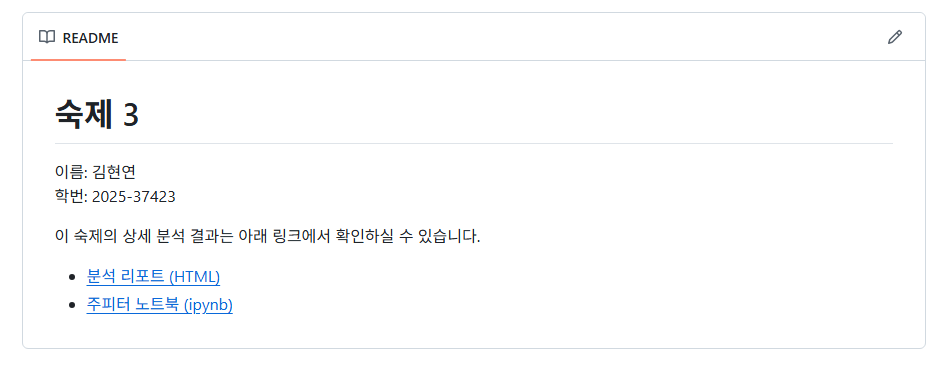
<figcaption>Figure 5: 저장소 페이지 (README 렌더링 결과)</figcaption>
</figure>